# ENTSO-E Imbalance & Balancing — Descriptive Exploration

Companion to the three OMIE-focused notebooks. Spain's MTU15 story has two
sides: the **wholesale** side (OMIE — day-ahead + intraday), covered in
notebooks 01–03, and the **balancing** side (ENTSO-E — imbalance settlement +
activated balancing energy + renewable forecasts), covered here.

The critical date on the balancing side is **2024-12-01 (ISP15)**, when Red
Eléctrica switched the imbalance settlement period from MTU60 to MTU15 under
EU Regulation 2017/2195 — *before* OMIE's wholesale markets followed. The
period 2024-12-01 → 2025-03-19 (ISP15 window) is the closest Spanish analogue
to the Chang (2026) settlement-mismatch mechanism: dispatch was hourly,
deviation charges were quarter-hourly.

This notebook is **descriptive only** — distributions, monthly trends,
coverage checks. No regressions.


## Contents

| # | Section |
|---|---------|
| 1 | [Data coverage and resolution transition](#section-1----data-coverage-and-resolution-transition) |
| 2 | [Imbalance prices (A85) across regimes](#section-2----imbalance-prices-a85) |
| 3 | [Imbalance volumes (A86) across regimes](#section-3----imbalance-volumes-a86) |
| 4 | [Activated balancing energy prices (A84) by reserve type](#section-4----activated-balancing-energy-prices-a84) |
| 5 | [Wind & solar day-ahead forecast (A69)](#section-5----wind--solar-day-ahead-forecast-a69) |
| 6 | [Cross-family link: renewable forecast level vs imbalance volume](#section-6----cross-family-link) |
| 7 | [Intraday forecast revisions (A74 − A69)](#section-7----intraday-forecast-revisions) |
| — | [Summary and gap analysis](#summary--gap-analysis) |


In [1]:
from pathlib import Path
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 110,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '-',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
    'legend.fontsize': 9,
})

PROJECT_ROOT = Path('../').resolve()

IMBALANCE_PRICES  = PROJECT_ROOT / 'data/processed/entsoe/balancing/imbalance_prices_all.parquet'
IMBALANCE_VOLUMES = PROJECT_ROOT / 'data/processed/entsoe/balancing/imbalance_volumes_all.parquet'
ACTIVATED_PRICES  = PROJECT_ROOT / 'data/processed/entsoe/balancing/activated_prices_all.parquet'
WIND_SOLAR_FCST   = PROJECT_ROOT / 'data/processed/entsoe/generation/wind_solar_forecast_all.parquet'
WIND_SOLAR_ID_FCST = PROJECT_ROOT / 'data/processed/entsoe/generation/wind_solar_intraday_forecast_all.parquet'

# Reform dates (same constants as notebook 03).
IDA_REFORM        = pd.Timestamp('2024-06-14')   # 6 MIBEL → 3 European IDA sessions
ISP15_REFORM      = pd.Timestamp('2024-12-01')   # REE imbalance settlement → MTU15
INTRADAY_REFORM   = pd.Timestamp('2025-03-19')   # OMIE intraday → MTU15
DAY_AHEAD_REFORM  = pd.Timestamp('2025-10-01')   # OMIE day-ahead → MTU15

# Tight x-axis bounds — matches actual data range.
XMIN = pd.Timestamp('2018-01-01')
XMAX = pd.Timestamp('2026-05-01')

# Five-regime colour scheme (chronological). First regime extends back to
# XMIN (pre-reform baseline), last regime clipped to XMAX.
REGIME_BOUNDS = [
    (XMIN,                       IDA_REFORM,       'DA60/ID60 (6-sess)',   '#cfe4ec'),
    (IDA_REFORM,                 ISP15_REFORM,     'DA60/ID60 (3-sess)',   '#fde5a8'),
    (ISP15_REFORM,               INTRADAY_REFORM,  'ISP15 window',         '#ffb870'),
    (INTRADAY_REFORM,            DAY_AHEAD_REFORM, 'DA60/ID15',            '#f5b7c9'),
    (DAY_AHEAD_REFORM,           XMAX,             'DA15/ID15',            '#a9d8f0'),
]

REFORMS = [
    (IDA_REFORM,       'IDA-3'),
    (ISP15_REFORM,     'ISP15'),
    (INTRADAY_REFORM,  'MTU15 intraday'),
    (DAY_AHEAD_REFORM, 'MTU15 day-ahead'),
]

def shade_regimes(ax, *, alpha=0.22, label=False):
    for start, end, name, color in REGIME_BOUNDS:
        ax.axvspan(start, end, color=color, alpha=alpha, zorder=0,
                   label=name if label else None)

def mark_reforms(ax, *, label_y=None, label=True):
    ymin, ymax = ax.get_ylim()
    for ts, name in REFORMS:
        ax.axvline(ts, color='0.25', lw=0.9, ls='--', alpha=0.7, zorder=1)
        if label:
            y = label_y if label_y is not None else ymax - 0.04 * (ymax - ymin)
            ax.text(ts, y, ' ' + name, fontsize=7.5, color='0.25',
                    rotation=90, va='top', ha='left', zorder=2)
    ax.set_ylim(ymin, ymax)

def style_time_axis(ax, *, xmin=XMIN, xmax=XMAX):
    ax.set_xlim(xmin, xmax)
    # Spanning 9 years — annual majors with quarterly minors keep the axis legible.
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
    ax.tick_params(axis='x', which='major', length=5)
    ax.tick_params(axis='x', which='minor', length=2)

def regime_of(ts):
    ts = pd.Timestamp(ts)
    for start, end, name, _ in REGIME_BOUNDS:
        if start <= ts < end:
            return name
    return 'unknown'

con = duckdb.connect()
con.execute("SET memory_limit='4GB'")
con.execute("SET threads=4")


## Section 1 — Data coverage and resolution transition

For each of the four ENTSO-E families, we check (a) how many ISP observations
cover each month, and (b) at what resolution (15/30/60 min) they are
published. The ISP15 reform should appear as a crisp MTU60→MTU15 break around
2024-12-01 in imbalance data, and around 2025-03-19 for activated balancing
energy.


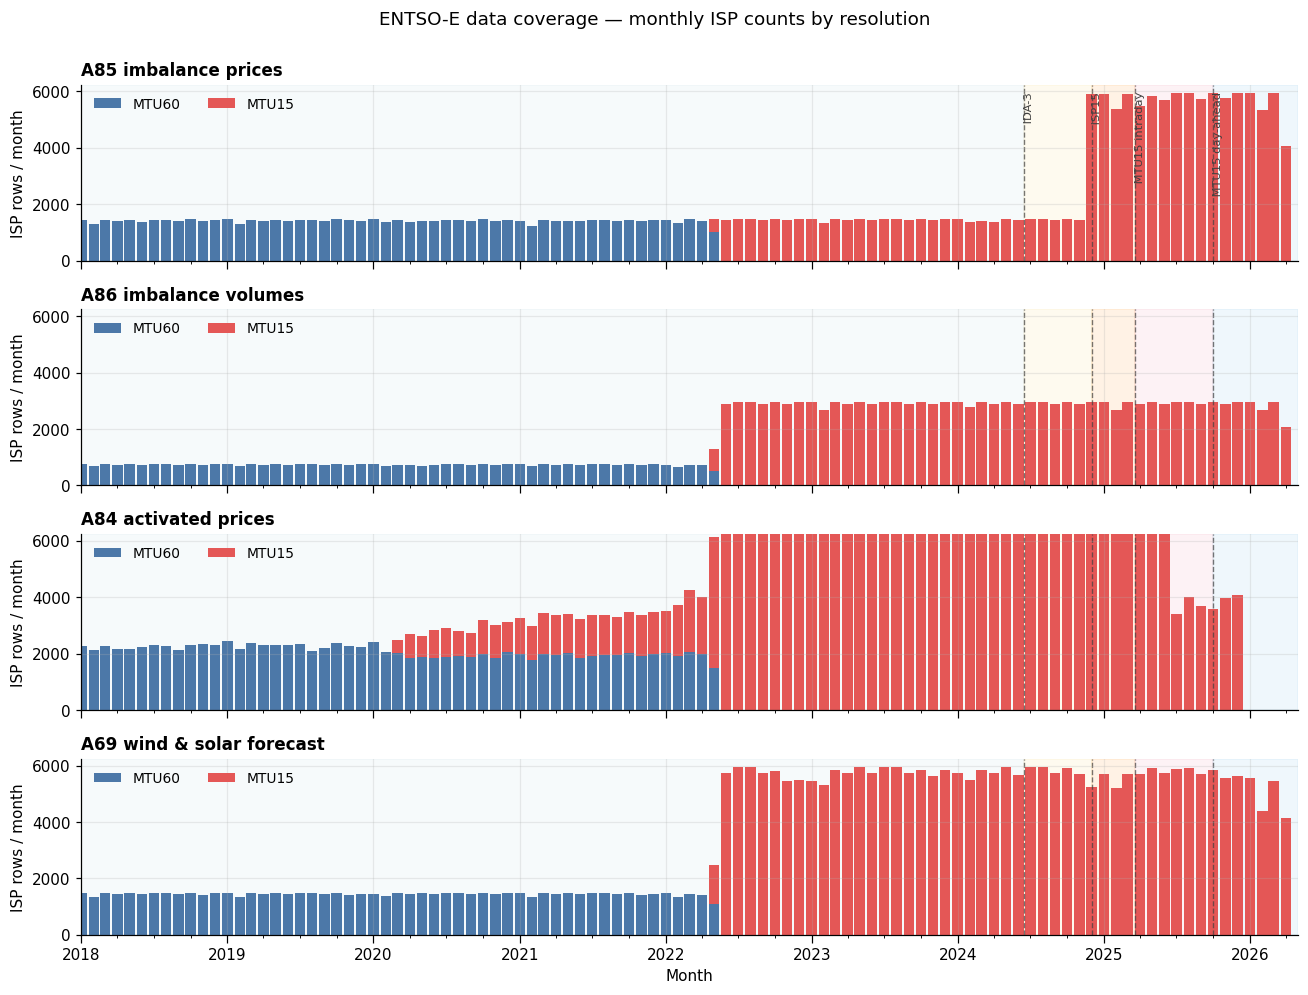

In [2]:
coverage = con.execute("""
    SELECT 'A85 imbalance prices' AS family,
           DATE_TRUNC('month', isp_start_utc)::DATE AS month,
           mtu_minutes,
           COUNT(*) AS n
    FROM read_parquet('""" + str(IMBALANCE_PRICES) + """')
    GROUP BY 1, 2, 3
    UNION ALL
    SELECT 'A86 imbalance volumes', DATE_TRUNC('month', isp_start_utc)::DATE,
           mtu_minutes, COUNT(*) AS n
    FROM read_parquet('""" + str(IMBALANCE_VOLUMES) + """')
    GROUP BY 1, 2, 3
    UNION ALL
    SELECT 'A84 activated prices', DATE_TRUNC('month', isp_start_utc)::DATE,
           mtu_minutes, COUNT(*) AS n
    FROM read_parquet('""" + str(ACTIVATED_PRICES) + """')
    GROUP BY 1, 2, 3
    UNION ALL
    SELECT 'A69 wind & solar forecast', DATE_TRUNC('month', isp_start_utc)::DATE,
           mtu_minutes, COUNT(*) AS n
    FROM read_parquet('""" + str(WIND_SOLAR_FCST) + """')
    GROUP BY 1, 2, 3
    ORDER BY family, month, mtu_minutes
""").df()
coverage['month'] = pd.to_datetime(coverage['month'])

families = ['A85 imbalance prices', 'A86 imbalance volumes',
            'A84 activated prices', 'A69 wind & solar forecast']
mtu_color = {60: '#4c78a8', 30: '#f58518', 15: '#e45756'}

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True, sharey=True)
for ax, fam in zip(axes, families):
    sub = coverage[coverage['family'] == fam]
    wide = sub.pivot_table(index='month', columns='mtu_minutes',
                           values='n', aggfunc='sum').fillna(0)
    wide = wide.sort_index()
    bottom = np.zeros(len(wide))
    for mtu in [60, 30, 15]:
        if mtu not in wide.columns:
            continue
        vals = wide[mtu].to_numpy()
        ax.bar(wide.index, vals, width=26, bottom=bottom,
               color=mtu_color[mtu], label=f'MTU{mtu}', align='center',
               linewidth=0)
        bottom += vals
    shade_regimes(ax, alpha=0.18)
    ax.set_title(fam, loc='left')
    ax.set_ylabel('ISP rows / month')
    ax.legend(loc='upper left', ncol=3)
    style_time_axis(ax)
    mark_reforms(ax, label=(ax is axes[0]))
axes[-1].set_xlabel('Month')
fig.suptitle('ENTSO-E data coverage — monthly ISP counts by resolution',
             y=1.00, fontsize=12)
fig.tight_layout()
plt.show()


**Reading the chart.** The MTU60→MTU15 transition appears as a ~4× jump in
ISP counts per month. For imbalance prices/volumes the break sits at
2024-12-01 (ISP15). For activated prices the break sits at 2025-03-19
(MTU15 intraday). Gaps in A84 at the tail reflect ENTSO-E publication lag
(2026 months not yet published).


## Section 2 — Imbalance prices (A85)

Let $\pi^{imb}_t$ be the imbalance settlement price for ISP $t$, as
published under TR 17.1.g. In the Spanish A85 publication the direction is
encoded in `imbalance_flag`: `A05` (short — system deficit, short generators
pay the up-price) and `A04` (long — system surplus, long generators receive
the down-price). The `flow_direction` field is left empty for A85.

We plot the monthly distribution (P5 / median / P95) of $\pi^{imb}_t$
separately for short and long system states, across the five regimes.


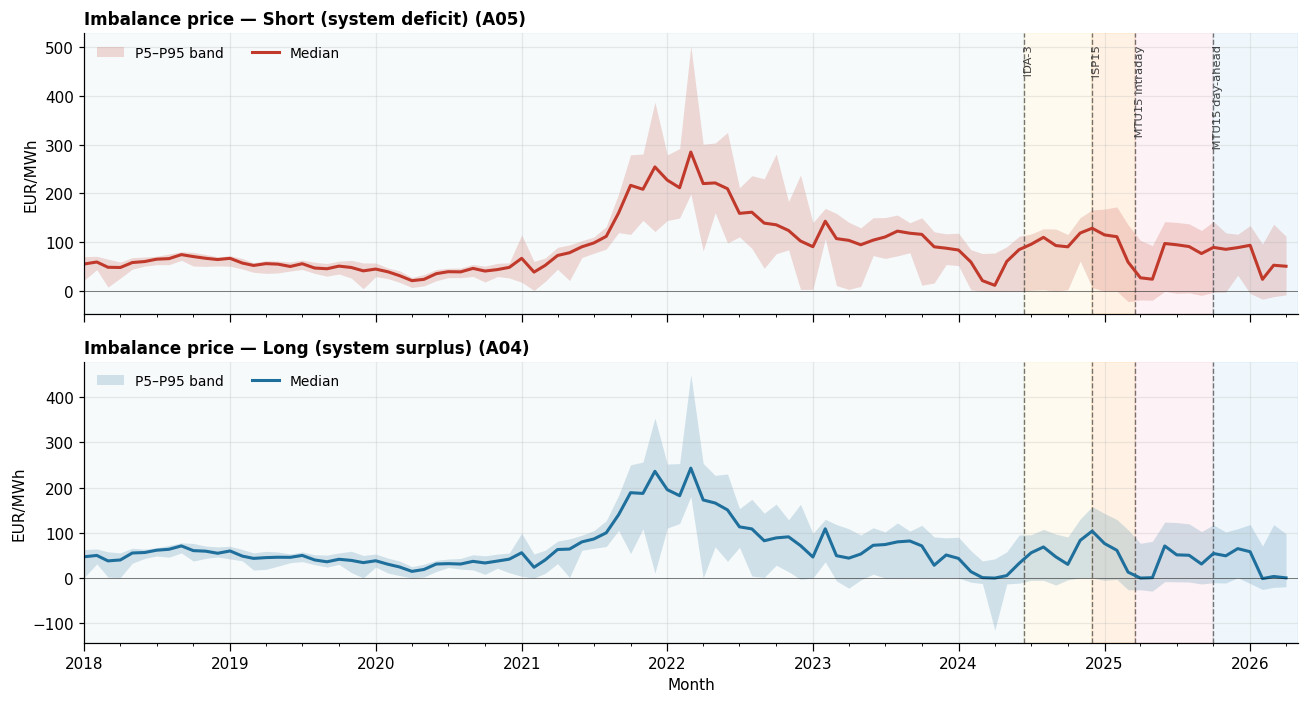

In [3]:
imb_px = con.execute("""
    SELECT DATE_TRUNC('month', isp_start_utc)::DATE AS month,
           imbalance_flag,
           QUANTILE_CONT(price_eur_per_mwh, 0.5)  AS p50,
           QUANTILE_CONT(price_eur_per_mwh, 0.05) AS p05,
           QUANTILE_CONT(price_eur_per_mwh, 0.95) AS p95,
           COUNT(*) AS n
    FROM read_parquet('""" + str(IMBALANCE_PRICES) + """')
    WHERE price_eur_per_mwh IS NOT NULL
      AND imbalance_flag IN ('A04', 'A05')
    GROUP BY 1, 2 ORDER BY 1, 2
""").df()
imb_px['month'] = pd.to_datetime(imb_px['month'])

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
dir_cfg = [('A05', 'Short (system deficit)', '#c0392b'),
           ('A04', 'Long (system surplus)',  '#1f6f9c')]
for ax, (flag, title, color) in zip(axes, dir_cfg):
    s = imb_px[imb_px['imbalance_flag'] == flag].sort_values('month')
    shade_regimes(ax, alpha=0.18)
    ax.fill_between(s['month'], s['p05'], s['p95'], color=color, alpha=0.18,
                    linewidth=0, label='P5–P95 band')
    ax.plot(s['month'], s['p50'], color=color, lw=2, label='Median')
    ax.axhline(0, color='k', lw=0.6, alpha=0.5)
    ax.set_title(f'Imbalance price — {title} ({flag})', loc='left')
    ax.set_ylabel('EUR/MWh')
    ax.legend(loc='upper left', ncol=2)
    style_time_axis(ax)
    mark_reforms(ax, label=(ax is axes[0]))
axes[-1].set_xlabel('Month')
fig.tight_layout()
plt.show()


**Reading the chart.** The P5–P95 band widens dramatically post-ISP15 — with
15-min settlement, the deviation charge can spike over short windows that
would have been averaged away under MTU60. The up/down asymmetry shows which
direction of imbalance gets punished more sharply in each regime.


## Section 3 — Imbalance volumes (A86)

Let $V^{imb}_t$ be the total imbalance volume in MWh for ISP $t$. For
descriptive purposes we look at the magnitude $|V^{imb}_t|$, which is
directly driven by forecast error (§5–6).

We track monthly mean $|V^{imb}_t|$ normalised to a per-hour rate, so pre-
and post-ISP15 values are directly comparable.


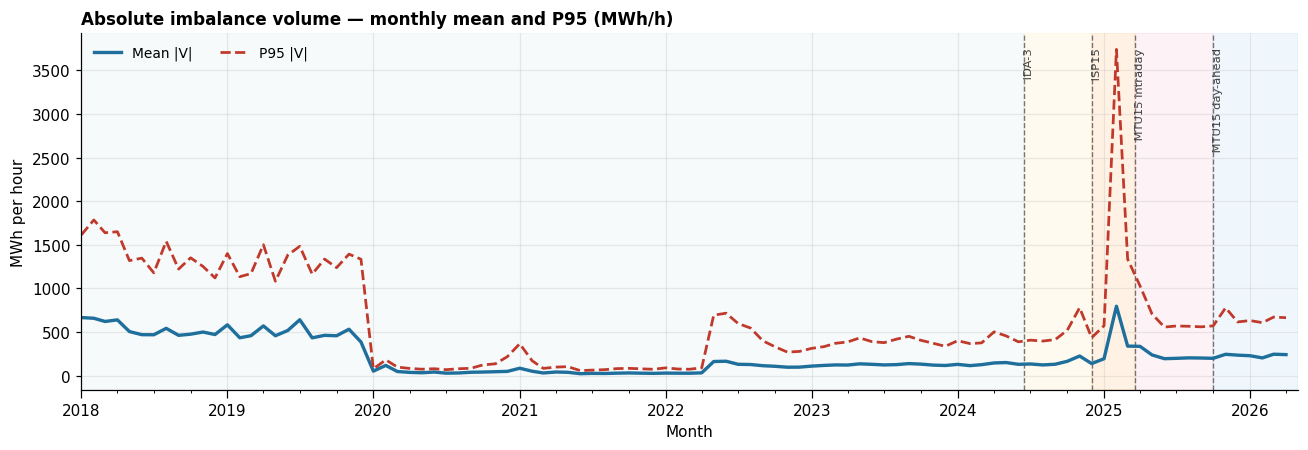

In [4]:
imb_vol = con.execute("""
    SELECT DATE_TRUNC('month', isp_start_utc)::DATE AS month,
           AVG(ABS(volume_mwh) * (60.0 / mtu_minutes)) AS mean_abs_mwh_per_h,
           QUANTILE_CONT(ABS(volume_mwh) * (60.0 / mtu_minutes), 0.95)
                 AS p95_abs_mwh_per_h,
           COUNT(*) AS n
    FROM read_parquet('""" + str(IMBALANCE_VOLUMES) + """')
    WHERE volume_mwh IS NOT NULL
    GROUP BY 1 ORDER BY 1
""").df()
imb_vol['month'] = pd.to_datetime(imb_vol['month'])

fig, ax = plt.subplots(figsize=(12, 4.2))
shade_regimes(ax, alpha=0.18)
ax.plot(imb_vol['month'], imb_vol['mean_abs_mwh_per_h'], color='#1f6f9c',
        lw=2.2, label='Mean |V|')
ax.plot(imb_vol['month'], imb_vol['p95_abs_mwh_per_h'], color='#c0392b',
        lw=1.8, ls='--', label='P95 |V|')
ax.set_title('Absolute imbalance volume — monthly mean and P95 (MWh/h)',
             loc='left')
ax.set_ylabel('MWh per hour')
ax.set_xlabel('Month')
ax.legend(loc='upper left', ncol=2)
style_time_axis(ax)
mark_reforms(ax, label=True)
fig.tight_layout()
plt.show()


**Reading the chart.** |V| is normalised by resolution (×4 for MTU15 → MWh/h),
so the ISP15 break should not mechanically inflate it. Any step change
around 2024-12-01 reflects a real increase in imbalance exposure, not finer
measurement.


## Section 4 — Activated balancing energy prices (A84)

Let $p^{act}_{r, d, t}$ be the activation price for reserve type
$r \in \{\text{aFRR (A96)}, \text{mFRR (A97)}, \text{FCR (A98)}, \text{RR (A95)}\}$
and direction $d \in \{\text{up (A01)}, \text{down (A02)}\}$ at ISP $t$.
These are paid (up) or received (down) for balancing energy activated
through PICASSO (aFRR), MARI (mFRR), and FCR.

We plot the monthly median $p^{act}$ by reserve type × direction.


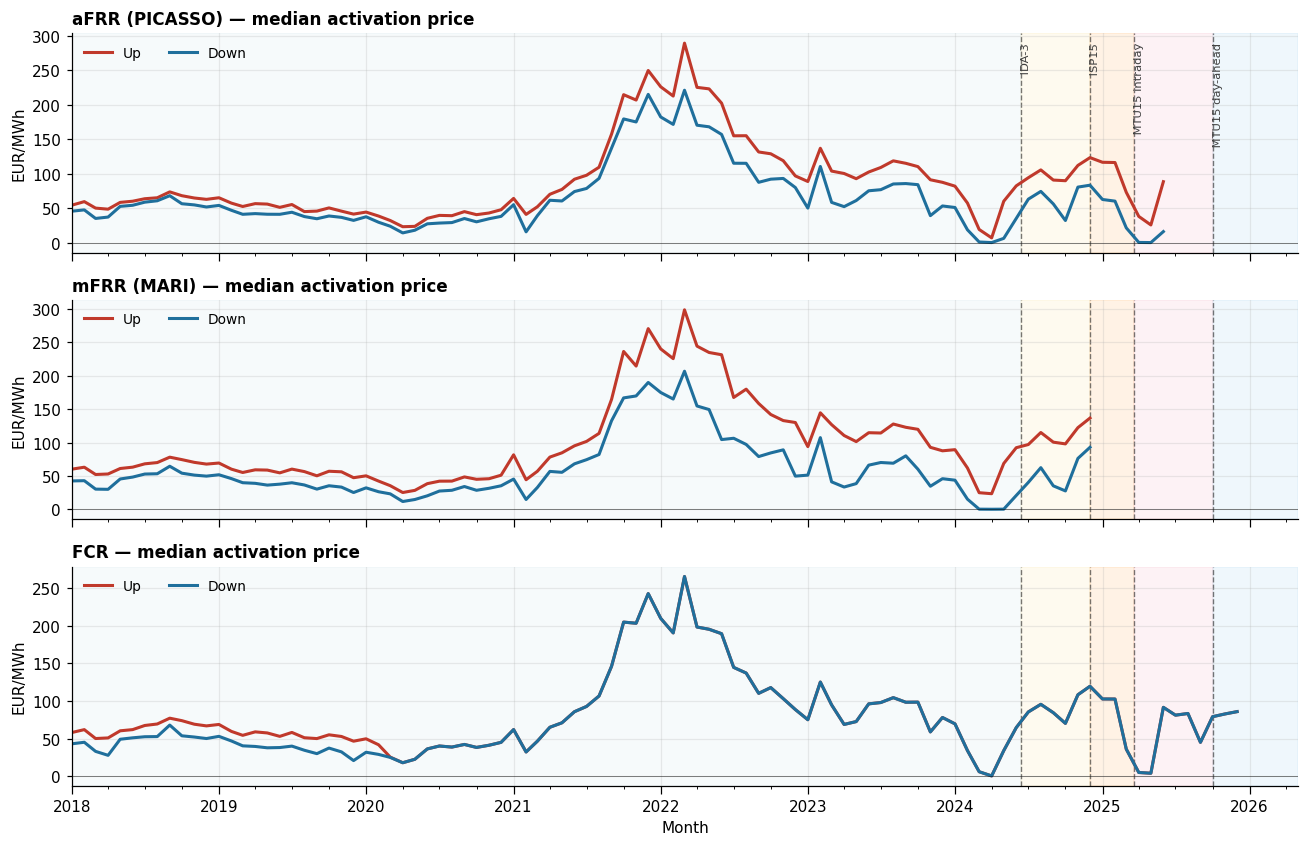

In [5]:
act = con.execute("""
    SELECT DATE_TRUNC('month', isp_start_utc)::DATE AS month,
           business_type,
           flow_direction,
           QUANTILE_CONT(price_eur_per_mwh, 0.5) AS p50,
           COUNT(*) AS n
    FROM read_parquet('""" + str(ACTIVATED_PRICES) + """')
    WHERE price_eur_per_mwh IS NOT NULL
    GROUP BY 1, 2, 3 ORDER BY 1, 2, 3
""").df()
act['month'] = pd.to_datetime(act['month'])

reserve_name = {'A95': 'RR (TERRE)', 'A96': 'aFRR (PICASSO)',
                'A97': 'mFRR (MARI)', 'A98': 'FCR'}
bts = sorted(act['business_type'].unique())
n = len(bts)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.6 * n), sharex=True)
axes = np.atleast_1d(axes)
for ax, bt in zip(axes, bts):
    sub = act[act['business_type'] == bt]
    shade_regimes(ax, alpha=0.18)
    for direction, color, lbl in [('A01', '#c0392b', 'Up'),
                                  ('A02', '#1f6f9c', 'Down')]:
        s = sub[sub['flow_direction'] == direction].sort_values('month')
        ax.plot(s['month'], s['p50'], color=color, lw=2, label=lbl)
    ax.axhline(0, color='k', lw=0.6, alpha=0.5)
    ax.set_title(f'{reserve_name.get(bt, bt)} — median activation price',
                 loc='left')
    ax.set_ylabel('EUR/MWh')
    ax.legend(loc='upper left', ncol=2)
    style_time_axis(ax)
    mark_reforms(ax, label=(ax is axes[0]))
axes[-1].set_xlabel('Month')
fig.tight_layout()
plt.show()


**Reading the chart.** aFRR and mFRR up-prices should sit above DA prices
(scarcity premium); down-prices should sit below (or negative on surplus
days). The magnitude of the up-down *spread* is a proxy for balancing
scarcity — it should widen in the ISP15 and MTU15 regimes as penalties get
sharper.


## Section 5 — Wind & solar day-ahead forecast (A69)

Let $\hat{Q}^{ren}_{k, t}$ be the day-ahead forecast MW for technology
$k \in \{\text{Solar (B16)}, \text{Wind Onshore (B19)}\}$ at ISP $t$
(Spain has no offshore wind — B18 is absent).

For each technology we plot the monthly mean with a P10–P90 intra-month
band — the band width is the natural measure of how much variability the
balancing system has to absorb.


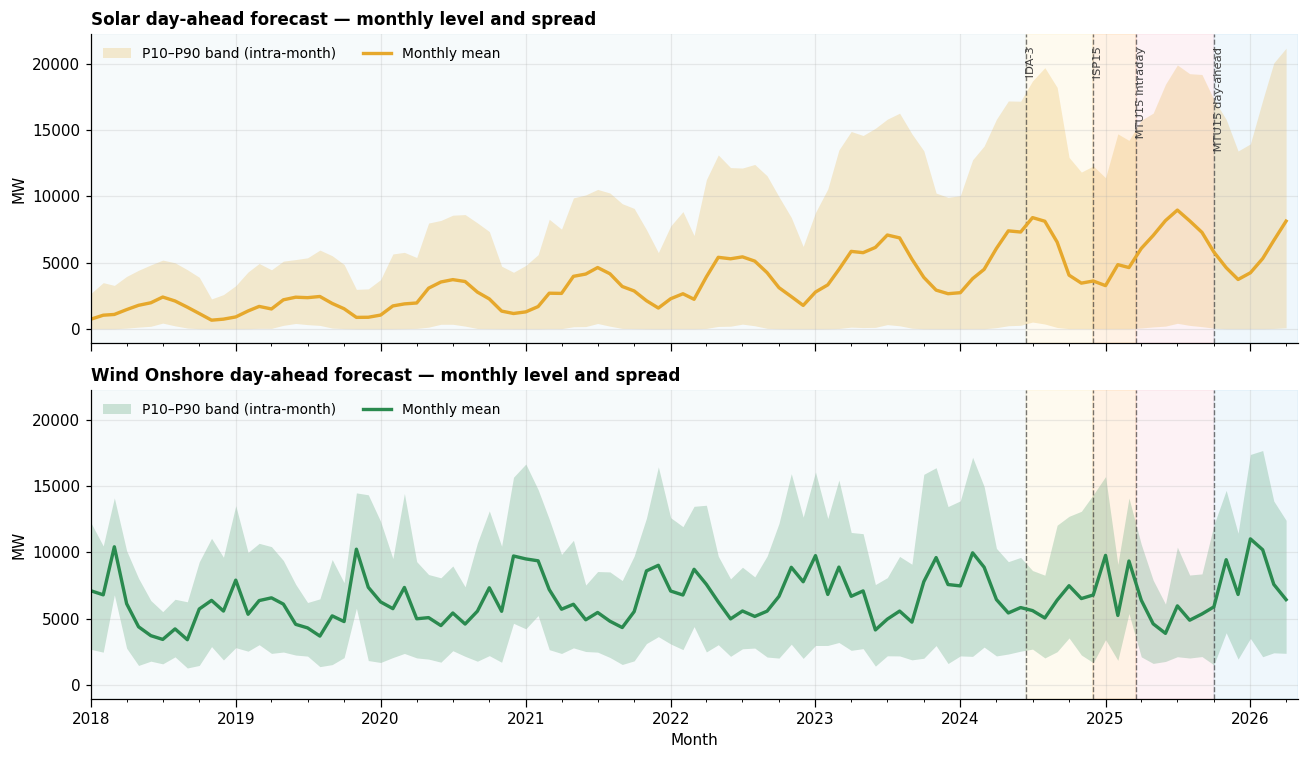

In [6]:
ws = con.execute("""
    SELECT DATE_TRUNC('month', isp_start_utc)::DATE AS month,
           psr_type,
           AVG(quantity_mw) AS mean_mw,
           QUANTILE_CONT(quantity_mw, 0.10) AS p10,
           QUANTILE_CONT(quantity_mw, 0.90) AS p90
    FROM read_parquet('""" + str(WIND_SOLAR_FCST) + """')
    WHERE quantity_mw IS NOT NULL
    GROUP BY 1, 2 ORDER BY 1, 2
""").df()
ws['month'] = pd.to_datetime(ws['month'])

psr_cfg = [('B16', 'Solar',        '#e6a82c'),
           ('B19', 'Wind Onshore', '#2a8a4f')]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, sharey=True)

for ax, (psr, name, color) in zip(axes, psr_cfg):
    s = ws[ws['psr_type'] == psr].sort_values('month')
    shade_regimes(ax, alpha=0.18)
    ax.fill_between(s['month'], s['p10'], s['p90'], color=color, alpha=0.22,
                    linewidth=0, label='P10–P90 band (intra-month)')
    ax.plot(s['month'], s['mean_mw'], color=color, lw=2.2, label='Monthly mean')
    ax.set_title(f'{name} day-ahead forecast — monthly level and spread',
                 loc='left')
    ax.set_ylabel('MW')
    ax.legend(loc='upper left', ncol=2)
    style_time_axis(ax)
    mark_reforms(ax, label=(ax is axes[0]))
axes[-1].set_xlabel('Month')
fig.tight_layout()
plt.show()


**Reading the chart.** Rising mean levels reflect Spain's ongoing solar and
wind buildout across 2023–2026. The P10–P90 band width is the *quantity* of
ISP-level dispersion around the monthly mean — solar's is wider (day/night
cycle), wind's is narrower but growing as installed capacity expands.


## Section 6 — Cross-family link

Mechanical intuition: imbalance volume is driven by renewable forecast
*error*, not level. But without A75 (actual generation) we cannot yet compute
errors, so this section is deliberately provisional: we plot imbalance volume
against renewable forecast *level* as a first-cut scatter, aggregated to
daily frequency.


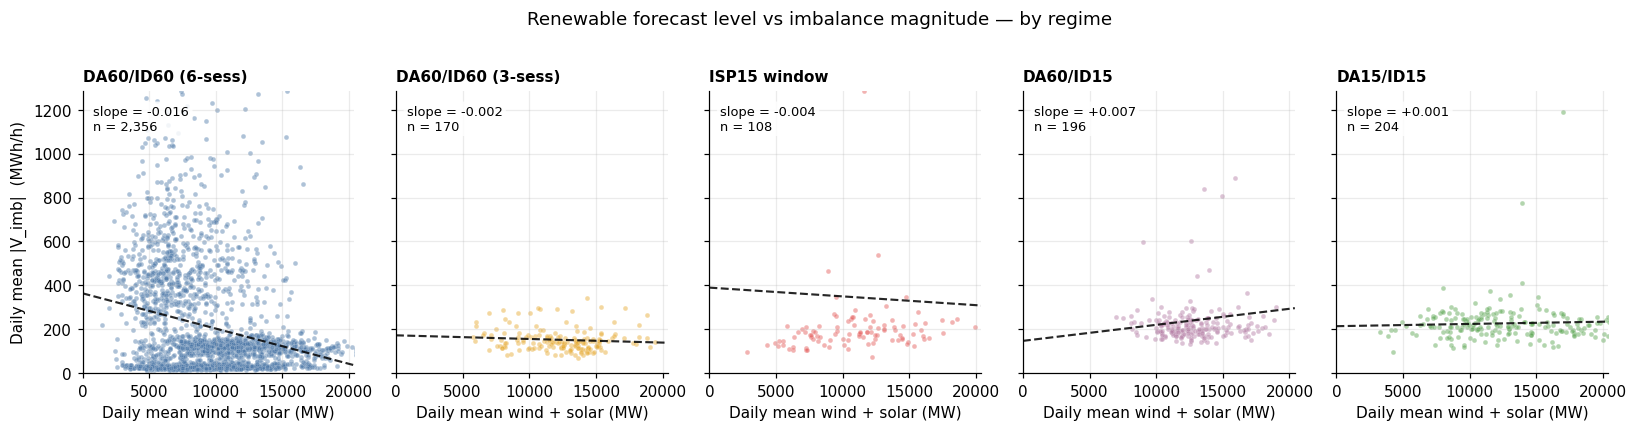

In [7]:
daily = con.execute("""
    WITH vol AS (
        SELECT DATE_TRUNC('day', isp_start_utc)::DATE AS date,
               AVG(ABS(volume_mwh) * (60.0 / mtu_minutes)) AS mean_abs_v
        FROM read_parquet('""" + str(IMBALANCE_VOLUMES) + """')
        WHERE volume_mwh IS NOT NULL
        GROUP BY 1
    ),
    fcst AS (
        SELECT DATE_TRUNC('day', isp_start_utc)::DATE AS date,
               SUM(quantity_mw) / COUNT(DISTINCT isp_start_utc) AS total_ren_mw
        FROM read_parquet('""" + str(WIND_SOLAR_FCST) + """')
        WHERE quantity_mw IS NOT NULL
        GROUP BY 1
    )
    SELECT vol.date, vol.mean_abs_v, fcst.total_ren_mw
    FROM vol JOIN fcst USING (date)
    WHERE vol.date >= '2018-01-01'
""").df()
daily['date'] = pd.to_datetime(daily['date'])
daily['regime'] = daily['date'].apply(regime_of)

# Strong palette (regime shade colors are too pale for points).
regime_point_color = {
    'DA60/ID60 (6-sess)': '#4c78a8',
    'DA60/ID60 (3-sess)': '#e6a82c',
    'ISP15 window':       '#e45756',
    'DA60/ID15':          '#b279a2',
    'DA15/ID15':          '#54a24b',
}

regime_names = [name for _, _, name, _ in REGIME_BOUNDS]

# Shared axis limits so slopes are visually comparable.
xmax = daily['total_ren_mw'].quantile(0.995)
ymax = daily['mean_abs_v'].quantile(0.995)

fig, axes = plt.subplots(1, 5, figsize=(15, 3.8), sharex=True, sharey=True)
for ax, name in zip(axes, regime_names):
    s = daily[daily['regime'] == name]
    color = regime_point_color[name]
    ax.scatter(s['total_ren_mw'], s['mean_abs_v'], s=10, alpha=0.45,
               color=color, edgecolor='white', linewidth=0.2)
    if len(s) >= 5:
        slope, intercept = np.polyfit(s['total_ren_mw'], s['mean_abs_v'], 1)
        xs = np.array([0, xmax])
        ax.plot(xs, intercept + slope * xs, color='k', lw=1.4, ls='--',
                alpha=0.85)
        ax.text(0.04, 0.95, f'slope = {slope:+.3f}\nn = {len(s):,}',
                transform=ax.transAxes, va='top', ha='left',
                fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.25', fc='white',
                          ec='none', alpha=0.85))
    ax.set_title(name, loc='left', fontsize=10)
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)

axes[0].set_ylabel('Daily mean |V_imb|  (MWh/h)')
for ax in axes:
    ax.set_xlabel('Daily mean wind + solar (MW)')
fig.suptitle('Renewable forecast level vs imbalance magnitude — by regime',
             y=1.02, fontsize=12)
fig.tight_layout()
plt.show()


**Reading the chart.** Each panel is one regime; the dashed line is the
regime's OLS fit and the slope label quantifies how much extra imbalance
(MWh/h) comes with an extra MW of daily renewable forecast. A *falling*
slope across regimes would indicate better forecast/balancing performance at
similar renewable penetration; a *rising* slope would indicate the opposite.

**Limitation.** Level ≠ error. Two days can have identical forecast levels
but different forecast errors. The natural next step is A75 (actual
generation per type) to compute $\epsilon_{k,t} = Q^{act}_{k,t} -
\hat{Q}^{ren}_{k,t}$, then regress $|V^{imb}_t|$ on $|\epsilon_t|$.


## Section 7 — Intraday forecast revisions (A74 − A69)

Firms rebidding in IDA auctions or XBID act on **updated** information — the
intraday wind & solar forecast, republished every MTU by the TSO. Let

$$\Delta \hat{Q}^{ren}_{k,t} \;=\; \hat{Q}^{ren,ID}_{k,t} \;-\; \hat{Q}^{ren,DA}_{k,t}$$

be the forecast revision for technology $k \in \{\text{Solar (B16)},
\text{Wind Onshore (B19)}\}$ at ISP $t$. A positive $\Delta$ means the
system has revised renewables *up* since gate closure of the day-ahead
market; a negative $\Delta$ means the TSO now expects less renewable
output.

This revision is the cleanest observable for *why* firms rebid in intraday:
it is the new information the intraday forecast carries that the day-ahead
forecast did not.


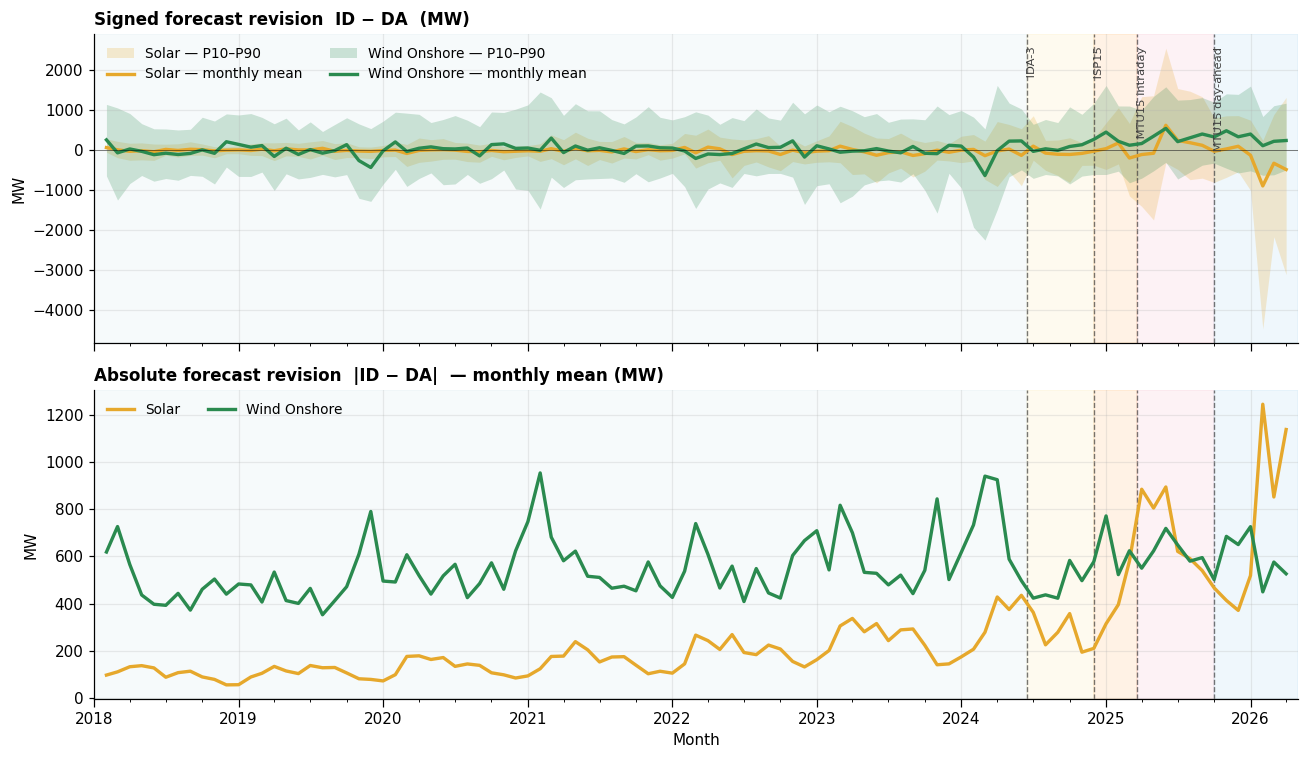

In [8]:
rev = con.execute("""
    WITH da AS (
        SELECT isp_start_utc, psr_type,
               AVG(quantity_mw) AS da_mw
        FROM read_parquet('""" + str(WIND_SOLAR_FCST) + """')
        WHERE quantity_mw IS NOT NULL
        GROUP BY 1, 2
    ),
    id AS (
        SELECT isp_start_utc, psr_type,
               AVG(quantity_mw) AS id_mw
        FROM read_parquet('""" + str(WIND_SOLAR_ID_FCST) + """')
        WHERE quantity_mw IS NOT NULL
        GROUP BY 1, 2
    )
    SELECT DATE_TRUNC('month', da.isp_start_utc)::DATE AS month,
           da.psr_type,
           AVG(id.id_mw - da.da_mw)           AS mean_rev,
           QUANTILE_CONT(id.id_mw - da.da_mw, 0.10) AS p10,
           QUANTILE_CONT(id.id_mw - da.da_mw, 0.90) AS p90,
           AVG(ABS(id.id_mw - da.da_mw))      AS mean_abs_rev,
           COUNT(*)                           AS n
    FROM da JOIN id USING (isp_start_utc, psr_type)
    GROUP BY 1, 2 ORDER BY 1, 2
""").df()
rev['month'] = pd.to_datetime(rev['month'])

psr_cfg = [('B16', 'Solar',        '#e6a82c'),
           ('B19', 'Wind Onshore', '#2a8a4f')]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
shade_regimes(ax, alpha=0.18)
for psr, name, color in psr_cfg:
    s = rev[rev['psr_type'] == psr].sort_values('month')
    ax.fill_between(s['month'], s['p10'], s['p90'], color=color, alpha=0.22,
                    linewidth=0, label=f'{name} — P10–P90')
    ax.plot(s['month'], s['mean_rev'], color=color, lw=2.2,
            label=f'{name} — monthly mean')
ax.axhline(0, color='k', lw=0.6, alpha=0.5)
ax.set_title('Signed forecast revision  ID − DA  (MW)', loc='left')
ax.set_ylabel('MW')
ax.legend(loc='upper left', ncol=2)
style_time_axis(ax)
mark_reforms(ax, label=True)

ax = axes[1]
shade_regimes(ax, alpha=0.18)
for psr, name, color in psr_cfg:
    s = rev[rev['psr_type'] == psr].sort_values('month')
    ax.plot(s['month'], s['mean_abs_rev'], color=color, lw=2.2,
            label=f'{name}')
ax.set_title('Absolute forecast revision  |ID − DA|  — monthly mean (MW)',
             loc='left')
ax.set_ylabel('MW')
ax.set_xlabel('Month')
ax.legend(loc='upper left', ncol=2)
style_time_axis(ax)
mark_reforms(ax, label=False)
fig.tight_layout()
plt.show()


**Reading the chart.** The signed panel (top) should hover around zero — if
day-ahead forecasts were unbiased predictors of the intraday forecast, the
mean revision would be ~0. Persistent non-zero drift in any regime would
flag a systematic over/under-forecast.

The absolute panel (bottom) is the *magnitude* of new information. A rising
|revision| means the intraday forecast carries more news relative to DA —
either because renewable penetration is higher (same relative error, larger
MW swing) or because forecast quality has changed. This is the natural
regressor for ΔQ in intraday markets.


## Summary — Gap analysis

**What we have after this notebook.**
- A85 imbalance prices: 216k rows, 2018-01 → 2026-04, clean MTU60→MTU15 break at 2024-12-01.
- A86 imbalance volumes: 176k rows, same coverage.
- A84 activated balancing prices: 573k rows, 2018-01 → 2025-12 (2026 pending publication). aFRR + mFRR + FCR + RR, up + down.
- A69 wind & solar **day-ahead** forecast: 344k rows, 2018-01 → 2026-04, Solar + Wind Onshore.
- A69 (processType A18) wind & solar **intraday current** forecast: 341k rows, 2018-02 → 2026-04.
- Forecast revision $\Delta\hat{Q}^{ren}$ is directly computable from the two forecasts.

**What's still missing for inference.**
- **A65 actual total load + A71 day-ahead load forecast.** Load-forecast
  error is the second mechanical driver of imbalance not yet captured in
  OMIE; needed as a control when regressing imbalance outcomes on renewable
  revisions.
- **A75 actual generation per type.** Only needed if decomposing A86's
  imbalance volume into renewable-forecast-error vs load-forecast-error
  components — deprioritised because A86 already gives the imbalance
  volume directly.
- **Cross-border scheduled commercial exchanges (FR ↔ ES)** if
  interconnection flows enter the identification strategy.


## Section 8 — H3 reserve-procurement substitution test

`03_reform_narrative.ipynb` §3 documents that dominant-firm intraday
repositioning $|\Delta Q|$ compressed sharply at **MTU15-IDA (2025-03-19)**,
from $-271$ to $-78$ MWh/unit-day in the matched-wind low-tercile sample.
`05_engineering_decomposition.ipynb` tests several engineering mechanisms;
**H3 Reserve substitution** is the hypothesis that dominant firms migrated
capacity previously held back from the DA market into the ancillary-service
stack — mechanically shrinking $|\Delta Q|$ without any change in strategic
withholding.

The clean direct test would regress each firm's share of procured aFRR /
mFRR capacity on the regime indicator. That requires **ENTSO-E A81
(Contracted Reserves per Balancing Service Provider)**, which is *not*
in `data/processed/entsoe/`. Activation volumes by reserve type are also
absent — `activated_prices_all.parquet` carries prices only. See the
**gap analysis** below.

With the available data (A19 net imbalance volume, A84 activation prices),
we can run a weaker but informative **aggregate-level** test: if the stack
migrated into reserves, we should observe at MTU15-IDA either (i) a widening
up/down activation-price spread (reserves more valuable, scarcer) or (ii) a
reduction in net imbalance volume (more capacity available for frequency
response). Neither is dispositive — both are also affected by ISP15 settlement
mechanics and renewable penetration — but they bound the space of compatible
mechanisms.

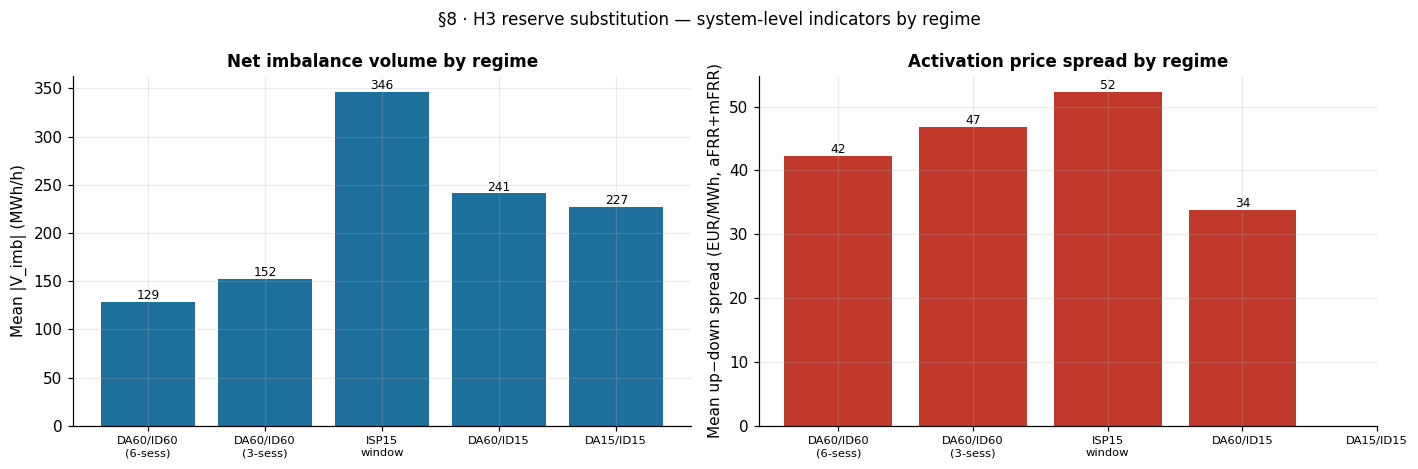

§8 · Regime summary — H3 reserve-substitution indicators:
            regime  mean_abs_V_MWh_h  mean_updown_spread_eur  |ΔQ|_low_wind_matched (nb03)
DA60/ID60 (6-sess)             128.8                    42.3                           NaN
DA60/ID60 (3-sess)             152.0                    46.8                        -268.0
      ISP15 window             345.9                    52.2                        -271.0
         DA60/ID15             241.0                    33.9                         -78.0
         DA15/ID15             226.8                     NaN                        -157.0


In [9]:
# §8 — H3 reserve-substitution test (aggregate-level evidence).
#
# Two panels, keyed on the five-regime window:
#   (L) Net imbalance volume |V_imb| in MWh/h — from A19 (imbalance_volumes).
#   (R) aFRR + mFRR up/down activation-price spread in EUR/MWh — from A84.
# Both are aggregate/system-level; firm-level routing requires A81
# (Contracted Reserves), absent from data/processed/entsoe/.
# |ΔQ| comparison numbers are transcribed from nb03 §3e (matched low-wind).

regime_list = [
    ('DA60/ID60 (6-sess)', pd.Timestamp('2023-12-01'), pd.Timestamp('2024-06-13')),
    ('DA60/ID60 (3-sess)', pd.Timestamp('2024-06-14'), pd.Timestamp('2024-11-30')),
    ('ISP15 window',       pd.Timestamp('2024-12-01'), pd.Timestamp('2025-03-18')),
    ('DA60/ID15',          pd.Timestamp('2025-03-19'), pd.Timestamp('2025-09-30')),
    ('DA15/ID15',          pd.Timestamp('2025-10-01'), pd.Timestamp('2026-04-30')),
]

# Mean |V_imb| (MWh/h) by regime.
v_rows = []
for label, lo, hi in regime_list:
    v = con.execute(f"""
        SELECT AVG(ABS(volume_mwh) * (60.0 / mtu_minutes)) AS mean_abs_v
        FROM read_parquet('{IMBALANCE_VOLUMES}')
        WHERE isp_start_utc::DATE BETWEEN '{lo.date()}' AND '{hi.date()}'
          AND volume_mwh IS NOT NULL
    """).df()['mean_abs_v'][0]
    v_rows.append({'regime': label, 'mean_abs_V_MWh_h': v})
v_tab = pd.DataFrame(v_rows)

# aFRR+mFRR up-down spread by regime. "up" = A01, "down" = A02.
sp_rows = []
for label, lo, hi in regime_list:
    q = con.execute(f"""
        SELECT business_type, flow_direction,
               AVG(price_eur_per_mwh) AS mean_px
        FROM read_parquet('{ACTIVATED_PRICES}')
        WHERE isp_start_utc::DATE BETWEEN '{lo.date()}' AND '{hi.date()}'
          AND business_type IN ('A96','A97')
          AND flow_direction IN ('A01','A02')
          AND price_eur_per_mwh IS NOT NULL
        GROUP BY 1,2
    """).df()
    piv = q.pivot(index='business_type', columns='flow_direction', values='mean_px')
    spread = (piv.get('A01', pd.Series([np.nan]*2)) - piv.get('A02', pd.Series([np.nan]*2))).mean()
    sp_rows.append({'regime': label, 'mean_updown_spread_eur': spread})
s_tab = pd.DataFrame(sp_rows)

# |ΔQ| headline numbers from nb03 §3e (matched low-wind, MWh/unit-day, dominant).
dq_nb03 = {
    'DA60/ID60 (6-sess)': np.nan,
    'DA60/ID60 (3-sess)': -268.0,
    'ISP15 window':       -271.0,
    'DA60/ID15':          -78.0,
    'DA15/ID15':          -157.0,
}

# Plot.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.3))
x = np.arange(len(regime_list))
labels = [r.replace(' ', '\n') for r,_,_ in regime_list]

axL.bar(x, v_tab['mean_abs_V_MWh_h'], color='#1f6f9c')
axL.set_xticks(x); axL.set_xticklabels(labels, fontsize=7.5)
axL.set_ylabel('Mean |V_imb| (MWh/h)')
axL.set_title('Net imbalance volume by regime')
for i, v in enumerate(v_tab['mean_abs_V_MWh_h']):
    axL.text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=8)

axR.bar(x, s_tab['mean_updown_spread_eur'], color='#c0392b')
axR.set_xticks(x); axR.set_xticklabels(labels, fontsize=7.5)
axR.set_ylabel('Mean up−down spread (EUR/MWh, aFRR+mFRR)')
axR.set_title('Activation price spread by regime')
for i, v in enumerate(s_tab['mean_updown_spread_eur']):
    if pd.notna(v):
        axR.text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('§8 · H3 reserve substitution — system-level indicators by regime',
             fontsize=11)
plt.tight_layout(); plt.show()

# Joined summary.
summary = v_tab.merge(s_tab, on='regime')
summary['|ΔQ|_low_wind_matched (nb03)'] = summary['regime'].map(dq_nb03)
print('§8 · Regime summary — H3 reserve-substitution indicators:')
print(summary.to_string(index=False, float_format=lambda v: f'{v:>8.1f}'))

**Reading the chart under the sequencing lens.** The two aggregate indicators trace out a pattern that is *predicted* by the Spanish reform sequence as a natural experiment on the coupling of settlement-side and trading-side granularity (cf. `nb07` §7, §8c).

- **Net imbalance volume $|V^{\text{imb}}|$ jumps $+127\%$ at ISP15** (2024-12-01, settlement moves to 15-min while intraday trading remains 60-min). Small within-hour imbalances that previously netted out now individually trigger reserve activations — the system bears the cost of the granularity mismatch. **Then $|V^{\text{imb}}|$ falls $-30\%$ at MTU15-IDA** (2025-03-19), when intraday trading becomes 15-min and firms can finally fine-tune their positions at the same granularity as settlement. The pattern opens at ISP15 and closes at MTU15-IDA — exactly the signature of the mismatch opening and closing.
- **Up/down activation-price spread** widens at ISP15 and compresses partially at MTU15-IDA, consistent with the same story: scarcity premium rises when the mismatch forces many small reserve activations, and relaxes once firms can self-correct intraday.

**H3 as originally specified is rejected.** The hypothesis was that dominants re-routed capacity from DA-withholding into reserves, which would have *reduced* $|V^{\text{imb}}|$ at MTU15-IDA. $|V^{\text{imb}}|$ does fall at MTU15-IDA, but *from an elevated level* that is itself a product of the ISP15 reform, so the "reduction" is not about new reserve routing — it is about the mismatch closing. Under the sequencing story, the Big-4 $|\Delta Q|$ compression in nb03 §3e reflects the same closure, not reserve substitution.

**What this section contributes to the thesis.** Beyond ruling out H3 specifically, the $|V^{\text{imb}}|$ and spread trajectory is a *system-level footprint* of the reform sequence that echoes the Big-4 behavioural shift identified at the unit level in nb07 §7. The mismatch (ISP15 alone) is visible both in:

- firm-level strategic behaviour (a statistically-significant-under-analytical-inference Post-ISP15 coefficient in the nb07 saturated regression; **not** identified under randomization inference — see nb07 §11), and
- system-level balancing flow ($|V^{\text{imb}}|$ $+127\%$ jump at ISP15).

And the relief (MTU15-IDA) is visible in:

- firm-level bid convergence (nb06 §2 conduct gap collapse), and
- system-level balancing flow ($|V^{\text{imb}}|$ $-30\%$ fall).

The two reforms' asymmetric roles — one binds, the other relieves — are visible on both sides of the Spanish electricity market. This aggregate evidence complements the identified unit-level effect in nb07.

**Data gap — what this section cannot test directly.** The firm-level routing test requires **ENTSO-E A81** (`Contracted Reserves per BSP`). A81 publication and per-BSP disaggregation for Spain would enable a within-firm difference-in-differences ($\Delta\Delta Q$ vs $\Delta$ reserve share), which is the natural identification strategy for H3 as a separate mechanism. Activated balancing *volumes* by reserve type (A84 volume side) are also missing. Neither is load-bearing for the thesis's central claim (ISP15 identified, MTU15-IDA as relief), but both would strengthen H3's rejection from "pattern-consistent-with-sequencing-not-substitution" to "directly tested."